In [1]:
import numpy as np

np.random.seed(42)

m = 200  # numero de ejemplos de entrenamiento
X = np.random.randn(2, m)  # shape: (n_features, m)

In [2]:
# Generamos etiquetas con una relacion lineal + ruido
y_true_logit = 0.8 * X[0] - 1.2 * X[1]
y = (y_true_logit + np.random.randn(m) * 0.5 > 0).astype(float)  # shape: (m,)

# Iniciamos parametros

n = X.shape[0]      # dimension de entrada: 2
w = np.zeros((n,))  # shape: (n,)
b = 0.0

alpha = 0.1   # tasa de aprendizaje
epochs = 500  # numero de iteraciones de gradiente descendente

# Funcion sigmoide
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

costos = []

for epoch in range(epochs):

    # FORWARD
    # Preactivacion: z = w^T * X + b
    # X tiene shape (n, m); w tiene shape (n,)
    # np.dot(w, X) produce un vector de shape (m,)
    z = np.dot(w, X) + b          # shape: (m,)

    # Activacion sigmoide: y_hat = sigma(z)
    # y_hat es la probabilidad estimada de incumplimiento
    y_hat = sigmoid(z)             # shape: (m,)

    # Funcion de Loss
    # L = -[y * log(y_hat) + (1-y) * log(1-y_hat)]
    # Promediamos sobre todos los m ejemplos para obtener el costo J
    # Usamos clip para evitar log(0), que es indefinido
    eps = 1e-8
    J = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

    # Backward - Backpropagation
    # Gradiente del costo con respecto a z:
    # dJ/dz = (1/m) * (y_hat - y)
    # Este es el resultado clave derivado en clase: el gradiente es el error
    dz = (y_hat - y)               # shape: (m,), sin dividir por m aun

    # Gradiente con respecto a w:
    # dJ/dw = (1/m) * X * dz^T
    # Como X tiene shape (n, m) y dz tiene shape (m,), np.dot produce (n,)
    dw = np.dot(X, dz) / m        # shape: (n,)

    # Gradiente con respecto a b:
    # dJ/db = (1/m) * sum(dz)
    db = np.mean(dz)               # escalar


    # Update de parametros
    # w <- w - alpha * dw
    # b <- b - alpha * db
    w = w - alpha * dw
    b = b - alpha * db

    # Guardamos el costo cada 50 epocas para monitoreo
    if epoch % 50 == 0:
        costos.append(J)
        print(f"Epoca {epoch:4d} | Costo J = {J:.6f}")

z_final = np.dot(w, X) + b
y_pred = (sigmoid(z_final) >= 0.5).astype(float)
accuracy = np.mean(y_pred == y)
print(f"\nExactitud final en entrenamiento: {accuracy*100:.1f}%")
print(f"Pesos aprendidos: w = {w}, b = {b:.4f}")

Epoca    0 | Costo J = 0.693147
Epoca   50 | Costo J = 0.413201
Epoca  100 | Costo J = 0.341129
Epoca  150 | Costo J = 0.307730
Epoca  200 | Costo J = 0.288361
Epoca  250 | Costo J = 0.275725
Epoca  300 | Costo J = 0.266856
Epoca  350 | Costo J = 0.260313
Epoca  400 | Costo J = 0.255306
Epoca  450 | Costo J = 0.251369

Exactitud final en entrenamiento: 89.0%
Pesos aprendidos: w = [ 1.66477373 -3.1010956 ], b = -0.2668


Costo J epoca 0: 0.693147
Costo J epoca 250: 0.275725
Costo J epoca final (499): 0.248204


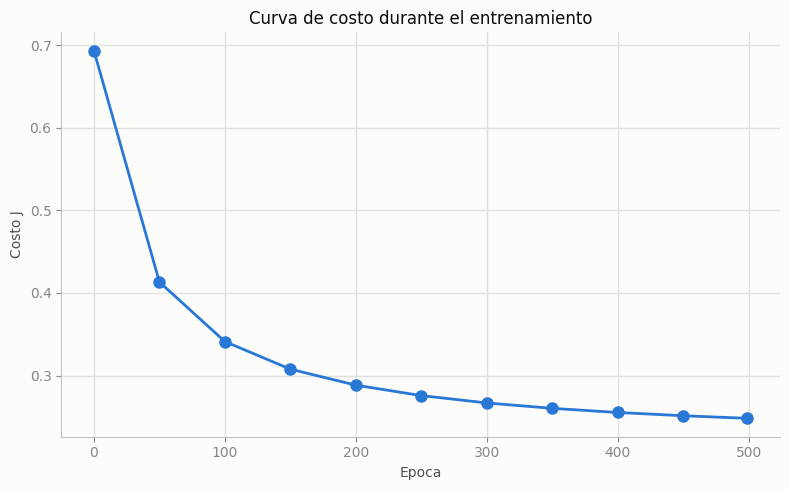

In [3]:
import matplotlib.pyplot as plt

# el loop solo guarda el costo cada 50 epocas, armamos el eje x correspondiente
epocas_graf = list(range(0, epochs, 50))
costos_graf = list(costos)

# la ultima epoca no cayo en el guardado cada 50, la calculamos aparte para cerrar la curva
J_final = -np.mean(y * np.log(sigmoid(z_final) + eps) + (1 - y) * np.log(1 - sigmoid(z_final) + eps))
epocas_graf.append(epochs - 1)
costos_graf.append(J_final)

print(f"Costo J epoca 0: {costos_graf[0]:.6f}")
print(f"Costo J epoca 250: {costos_graf[epocas_graf.index(250)]:.6f}")
print(f"Costo J epoca final ({epochs - 1}): {J_final:.6f}")

# graficamos la curva de costo vs epocas
plt.figure(figsize=(8, 5), facecolor="#fcfcfb")
ax = plt.gca()
ax.set_facecolor("#fcfcfb")
ax.plot(epocas_graf, costos_graf, color="#2a78d6", linewidth=2, marker="o", markersize=8)
ax.set_xlabel("Epoca", color="#52514e")
ax.set_ylabel("Costo J", color="#52514e")
ax.set_title("Curva de costo durante el entrenamiento", color="#0b0b0b")
ax.grid(True, color="#e1e0d9", linewidth=1)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.tick_params(colors="#898781")
plt.tight_layout()
plt.savefig("curva_costo.png", dpi=150, facecolor="#fcfcfb")
plt.show()
